# Convolutional Neural Network for Speech Enhancement

This notebook implements a CNN-based speech enhancement system that learns to remove noise from audio signals.


## 1 - Imports

Import the required libraries for audio processing, deep learning, and visualization.

In [1]:
import os
import numpy as np
import librosa
from IPython.display import Audio
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import joblib # efficient serialization for large arrays

from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
!nvidia-smi

Wed Jan 28 22:36:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2 - Datasets


### Clean Speech Source
We use the **LibriSpeech ASR Corpus** (dev-clean subset) as our source of clean speech recordings.

- Source: https://www.openslr.org/12
- Contains read English speech from audiobooks
- High-quality recordings suitable for training

### Noise
We add synthetic **white Gaussian noise** to create noisy-clean audio pairs.

In [4]:
# mount drive from Google Collab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!ls "/content/drive/MyDrive"

'Colab Notebooks'


In [6]:
# !mkdir "/content/drive/MyDrive/"

mkdir: cannot create directory ‘/content/drive/MyDrive/’: File exists


In [6]:
# !mkdir -p "/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data"

In [7]:
# # download Librispeech ASR (Automatic Speech Recognition) corpus
# !wget -P "/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data" \
# https://openslr.trmal.net/resources/12/dev-clean.tar.gz

In [8]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data/dev-clean.tar.gz"

-rw------- 1 root root 323M Oct  3  2017 '/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data/dev-clean.tar.gz'


In [9]:
# # unzip downloaded file gz file from librispeech
# !tar -xvzf "/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data/dev-clean.tar.gz" \
# -C "/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data"


## 3 - Configuration Parameters

### Audio Parameters
| Parameter | Value | Description |
|-----------|-------|-------------|
| `SAMPLE_RATE` | 22,500 Hz | Target sample rate for all audio |
| `DURATION` | 30 seconds | Maximum track duration |
| `segment_seconds` | 2 seconds | Length of each training segment |
| `stride_seconds` | 1 second | Overlap stride (50% overlap) |
| `WHITE_NOISE_FACTOR` | 0.1 | Noise intensity multiplier |

In [10]:
PROJECT_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data/"
DATASET_PATH = PROJECT_DATA_PATH + "LibriSpeech/dev-clean"

SAMPLE_RATE=22500
DURATION = 30 # measure d in seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

In [11]:
print(os.listdir(DATASET_PATH))

['7850', '1993', '6313', '5895', '2412', '5338', '2277', '3576', '6319', '1988', '84', '2035', '1673', '1462', '3536', '1919', '8842', '6345', '3081', '3853', '3170', '2803', '422', '2086', '2078', '6241', '5536', '3000', '6295', '3752', '2428', '777', '652', '5694', '7976', '174', '8297', '251', '1272', '2902']


In [13]:
print(f"Number of speakers in dataset: {len(os.listdir(DATASET_PATH))}")

Number of speakers in dataset: 40


## 4 - Data Preprocessing
### Create Audio Pairs

For each audio file:
1. Load the clean audio at the target sample rate
2. Add white noise to create the noisy version
3. Segment both signals into 2-second chunks with 1-second overlap
4. Store as (noisy, clean) pairs

In [13]:
# adding white noise
def add_white_noise(signal, noise_factor):
    noise = np.random.normal(0, signal.std(), signal.size)
    augmented_signal = signal + noise * noise_factor
    return augmented_signal

In [14]:
MAX_SPEAKERS = 40
MAX_CHAPTERS = 5
WHITE_NOISE_FACTOR = 0.1

audio_pairs = []
speakers = sorted(os.listdir(DATASET_PATH))[:MAX_SPEAKERS]

# loop over speaker IDs
for speaker_id in speakers:
    speaker_path = os.path.join(DATASET_PATH, speaker_id)

    if not os.path.isdir(speaker_path):
        continue

    print(f"Speaker: {speaker_id}")

    chapters = sorted(os.listdir(speaker_path))[:MAX_CHAPTERS]

    for chapter_id in chapters:
        chapter_path = os.path.join(speaker_path, chapter_id)

        if not os.path.isdir(chapter_path):
            continue

        print(f"  Chapter: {chapter_id}")

        # load files in chapter folder
        for filename in sorted(os.listdir(chapter_path)):
            if filename.endswith(".flac"):
                file_path = os.path.join(chapter_path, filename)

                try:
                  # print(f"    loading {file_path}", end=" ")
                  clean_signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
                  # print(f"({len(clean_signal)/ SAMPLE_RATE:.2f}s.)")

                  # print(f"    adding white noise...")
                  noisy_signal = add_white_noise(clean_signal, WHITE_NOISE_FACTOR)


                except Exception as e:
                    print("    SKIP:", file_path, "|", type(e).__name__, e)
                    continue

                # process segments for each file with overlap
                # drop remainder if signal length isn’t a multiple of 2 seconds
                segment_seconds = 2
                stride_seconds = 1

                segment_len = int(segment_seconds * SAMPLE_RATE)  # samples per segment
                stride_len  = int(stride_seconds * SAMPLE_RATE)

                for i, start_sample in enumerate(range(0, len(clean_signal) - segment_len + 1, stride_len)):
                  end_sample = start_sample + segment_len
                  # print(f"        Processing segment {i+1} ({start_sample}:{end_sample})")
                  audio_pairs.append((noisy_signal[start_sample:end_sample],
                                      clean_signal[start_sample:end_sample]))
    print()


Speaker: 1272
  Chapter: 128104
  Chapter: 135031
  Chapter: 141231

Speaker: 1462
  Chapter: 170138
  Chapter: 170142
  Chapter: 170145

Speaker: 1673
  Chapter: 143396
  Chapter: 143397

Speaker: 174
  Chapter: 168635
  Chapter: 50561
  Chapter: 84280

Speaker: 1919
  Chapter: 142785

Speaker: 1988
  Chapter: 147956
  Chapter: 148538
  Chapter: 24833

Speaker: 1993
  Chapter: 147149
  Chapter: 147964
  Chapter: 147965
  Chapter: 147966

Speaker: 2035
  Chapter: 147960
  Chapter: 147961
  Chapter: 152373

Speaker: 2078
  Chapter: 142845

Speaker: 2086
  Chapter: 149214
  Chapter: 149220

Speaker: 2277
  Chapter: 149874
  Chapter: 149896
  Chapter: 149897

Speaker: 2412
  Chapter: 153947
  Chapter: 153948
  Chapter: 153954

Speaker: 2428
  Chapter: 83699
  Chapter: 83705

Speaker: 251
  Chapter: 118436
  Chapter: 136532
  Chapter: 137823

Speaker: 2803
  Chapter: 154320
  Chapter: 154328
  Chapter: 161169

Speaker: 2902
  Chapter: 9006
  Chapter: 9008

Speaker: 3000
  Chapter: 15664

S

In [15]:
print(f"Number of audio pairs created: {len(audio_pairs)}")

Number of audio pairs created: 15321


In [16]:
Audio(data=audio_pairs[0][0], rate=SAMPLE_RATE)

In [17]:
Audio(data=audio_pairs[0][1], rate=SAMPLE_RATE)

## 5 - Mel Spectrogram Computation

### Spectrogram Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| `N_FFT` | 2048 | FFT window size |
| `HOP_LENGTH` | 512 | Samples between frames |
| `N_MELS` | 256 | Number of mel frequency bands |
| `power` | 2.0 | Power spectrogram (magnitude squared) |

In [16]:
N_FFT=2048
HOP_LENGTH=512
N_MELS=256
POWER = 2.0

In [19]:
def compute_mel_scaled_spectrogram(y,
                                   sr=SAMPLE_RATE,
                                   n_fft=N_FFT,
                                   hop_length=HOP_LENGTH,
                                   n_mels=N_MELS,
                                   power=2.0,
                                   center=False):
  S_mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=POWER,
    center=center,
  )

  # Return the natural logarithm of one plus the input array, element-wise.
  # Calculates log(1 + x)
  # S_mel_log1p = np.log1p(S_mel)

  # option B: consistent ref: 1.0 gives you a stable mapping
  S_mel_db = librosa.power_to_db(S_mel, ref=1.0).astype(np.float32)

  return S_mel_db

In [20]:
# generate pairs of clean-noisy spectrograms
spectrogram_pairs = []
for i, (noisy, clean) in tqdm(enumerate(audio_pairs), total=len(audio_pairs)):

  S_mel_db_noisy = compute_mel_scaled_spectrogram(noisy)
  S_mel_db_clean = compute_mel_scaled_spectrogram(clean)
  # print(i, clean.shape, S_mel_db_clean.shape)  # S_mel_db shape: (n_mels, frames)

  spectrogram_pairs.append((S_mel_db_noisy, S_mel_db_clean))

print("Saving spectrogram_pairs to disk...")
joblib.dump(
    spectrogram_pairs,
    PROJECT_DATA_PATH+"spectrogram_pairs.joblib",
    compress=("zlib", 3)
)
print("Saved spectrogram_pairs.joblib to disk successfully")

  0%|          | 0/15321 [00:00<?, ?it/s]

Saving spectrogram_pairs to disk...
Saved spectrogram_pairs.joblib to disk successfully


In [17]:
!ls -lh "$PROJECT_DATA_PATH""spectrogram_pairs.joblib"


-rw------- 1 root root 2.1G Jan 28 22:28 '/content/drive/MyDrive/Colab Notebooks/Audio Signal Processing/speech_enhancement_data/spectrogram_pairs.joblib'


## 6 - Visualizing Spectrograms

Side-by-side comparison of noisy and clean spectrograms.

In [18]:
def plot_spectrograms(spectrogram_1, spectrogram_2, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
    y_axis="linear", titles=("Noisy Spectrogram", "Clean Spectrogram"), cmap="magma"):

    fig, axes = plt.subplots(1, 2, figsize=(25, 8), sharex=True, sharey=True, constrained_layout=True)

    # Ensure both plots use the same color scale
    vmin = min(spectrogram_1.min(), spectrogram_2.min())
    vmax = max(spectrogram_1.max(), spectrogram_2.max())

    img1 = librosa.display.specshow(
        spectrogram_1,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        ax=axes[0]
    )
    axes[0].set_title(titles[0])

    img2 = librosa.display.specshow(
        spectrogram_2,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        ax=axes[1]
    )
    axes[1].set_title(titles[1])

    # Single shared colorbar
    cbar = fig.colorbar(img1, ax=axes, format="%+2.0f dB")
    cbar.set_label("Amplitude (dB)")

    # plt.tight_layout()
    plt.show()


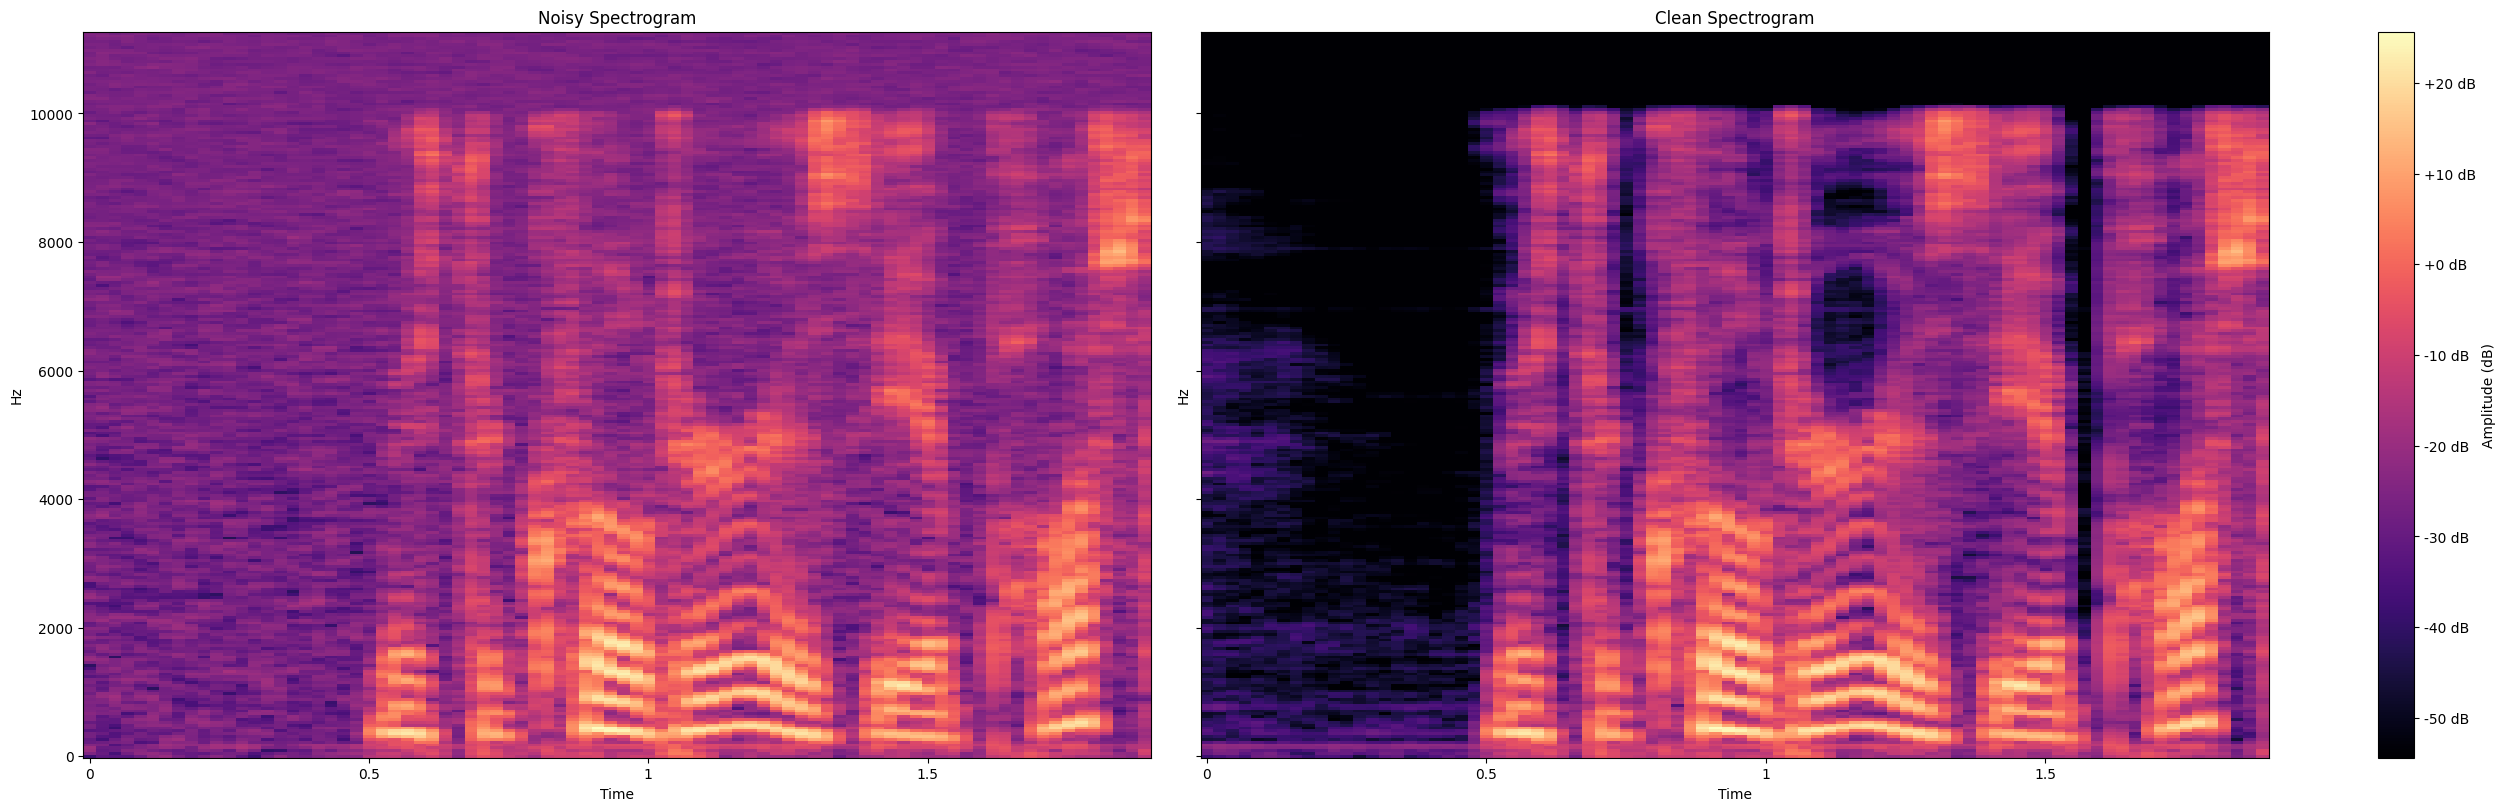

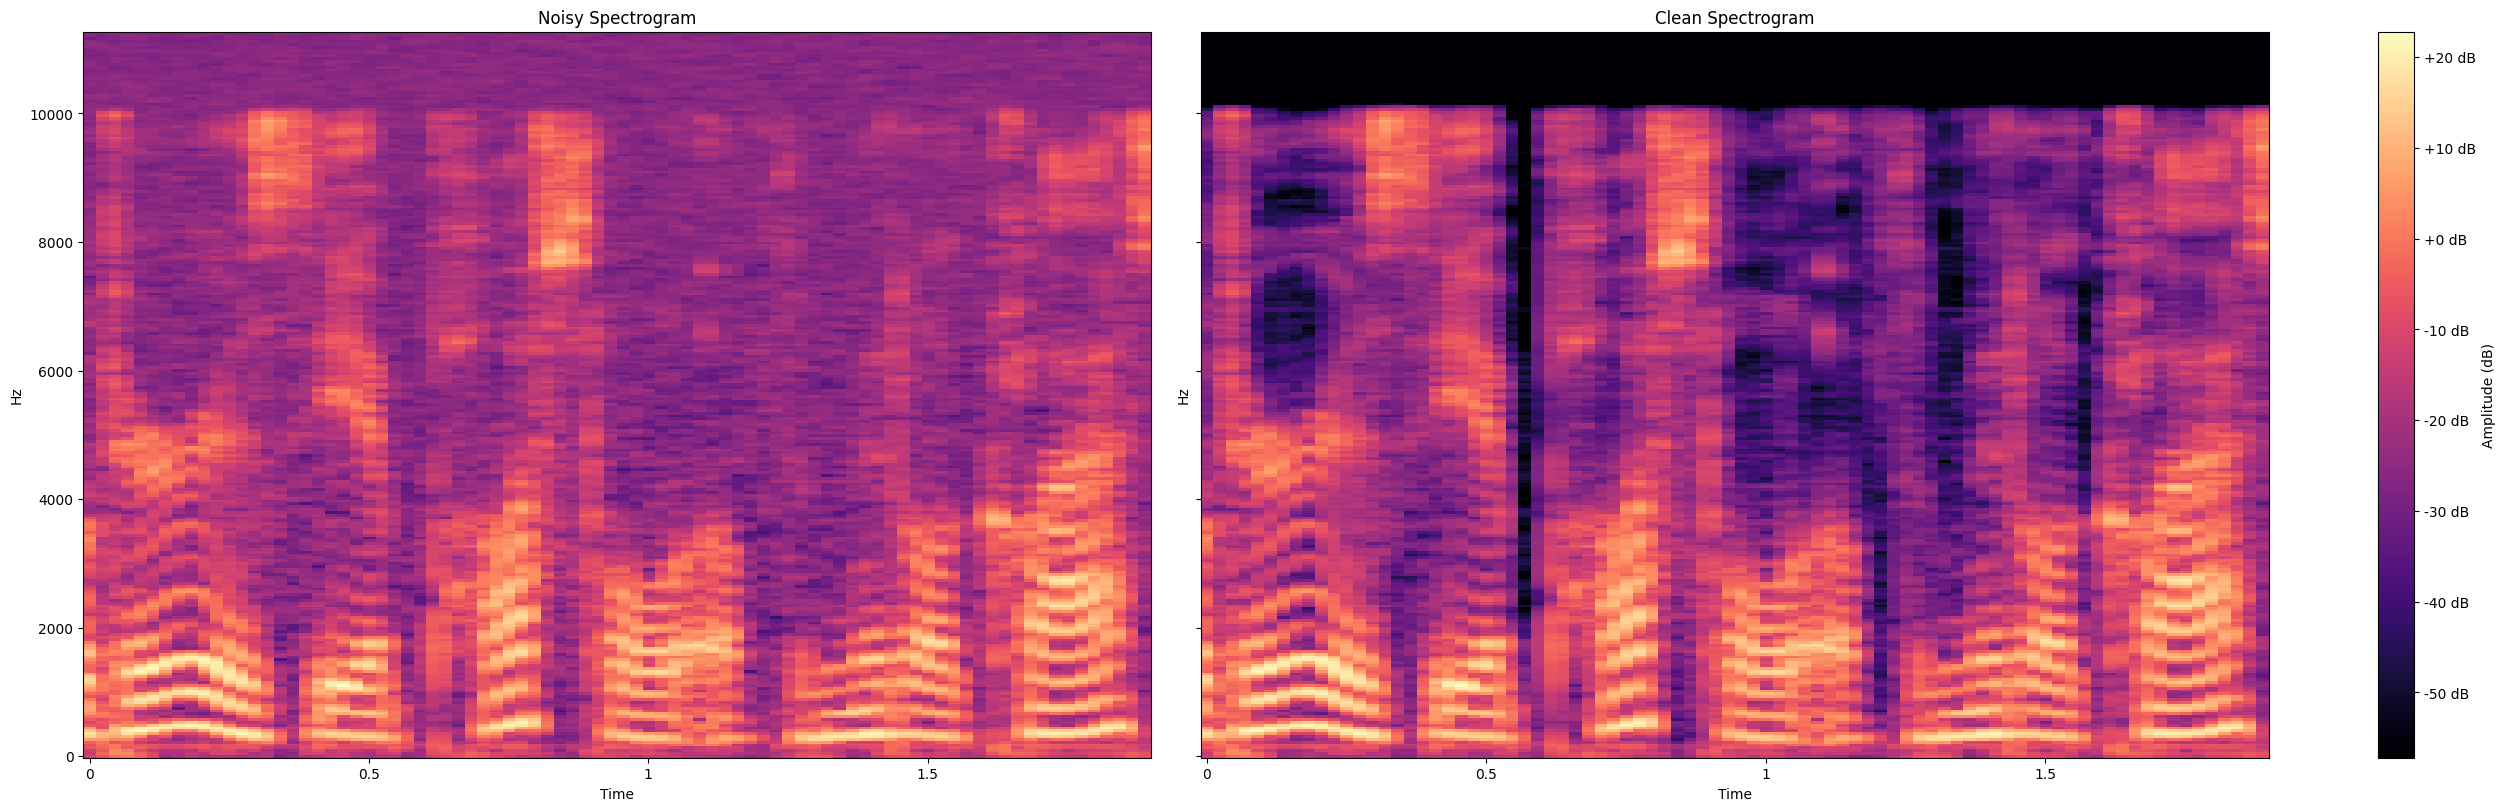

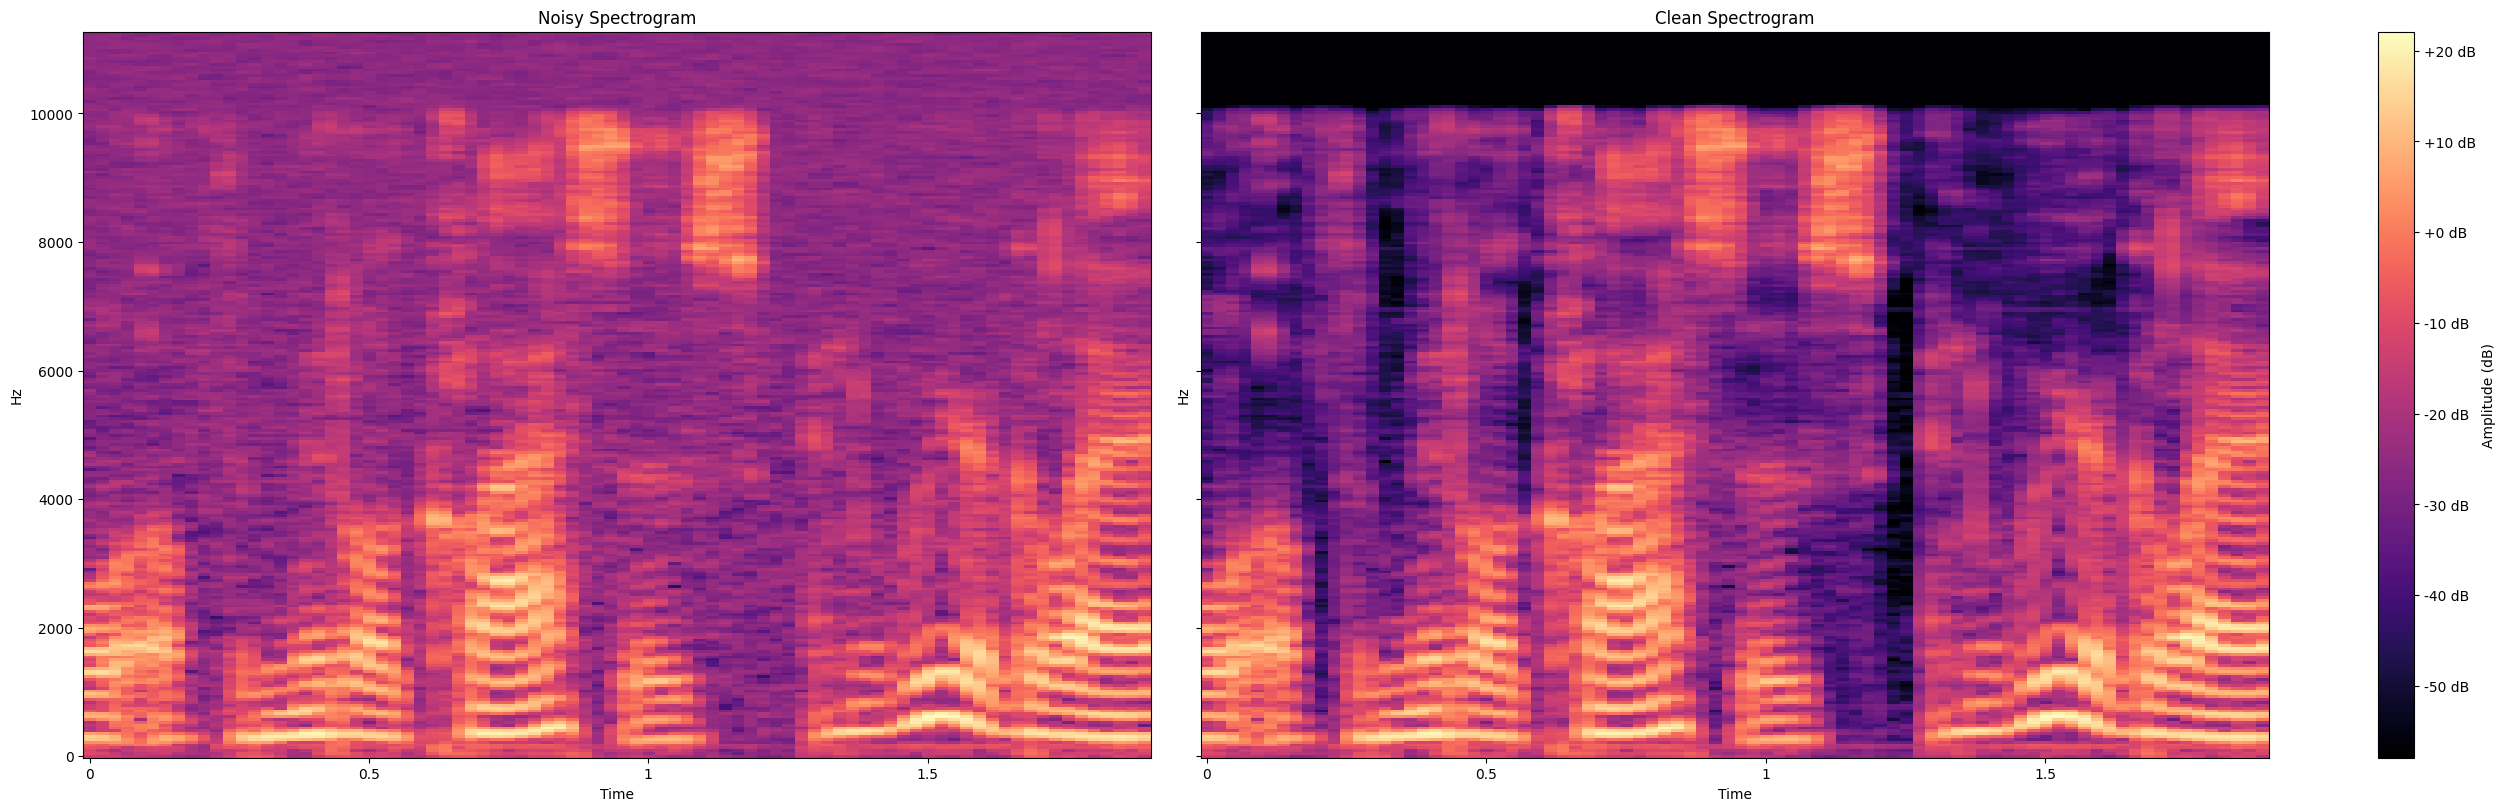

In [23]:
for (spec_noisy, spec_clean) in spectrogram_pairs[:3]:
  plot_spectrograms(spec_noisy, spec_clean)


## 7 - Data Preparation for Training

### 7.1 - Load data

In [19]:
def load_data(dataset_path):
  spectrogram_pairs = joblib.load(dataset_path)
  inputs, targets = map(np.array, zip(*spectrogram_pairs))

  return inputs, targets



### 7.2 - Train/Validation/Test Split

| Set | Proportion | Purpose |
|-----|------------|---------|
| Training | 60% | Model weight updates |
| Validation | 15% | Hyperparameter tuning, early stopping |
| Test | 25% | Final evaluation |

### Input Shape

The data is reshaped to include a channel dimension:
- From: `(n_samples, n_mels, n_frames)`
- To: `(n_samples, n_mels, n_frames, 1)`

This matches the expected input format for 2D convolution layers.

In [20]:
def prepare_datasets(test_size, validation_size):

  # load data
  inputs, targets = load_data(PROJECT_DATA_PATH+"spectrogram_pairs.joblib")

  print(f"inputs.shape: {inputs.shape} (n_segments, n_mels, n_frames)")
  print(f"targets.shape: {targets.shape} (n_segments, n_mels, n_frames)")


  # create train/test split
  X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=test_size)

  # create train/validation split
  X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=validation_size)

  # we need to add another dimension 3d array -> (10322, 80, 84, 1)
  X_train = X_train[..., np.newaxis] # 4d array -> (num_samples, 80, 84, 1)
  X_val = X_val[..., np.newaxis]
  X_test = X_test[..., np.newaxis]

  return X_train, X_val, X_test, y_train, y_val, y_test


In [21]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_datasets(0.25, 0.2)
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

inputs.shape: (15321, 256, 84) (n_segments, n_mels, n_frames)
targets.shape: (15321, 256, 84) (n_segments, n_mels, n_frames)


((9192, 256, 84, 1),
 (2298, 256, 84, 1),
 (3831, 256, 84, 1),
 (9192, 256, 84),
 (2298, 256, 84),
 (3831, 256, 84))

## 8 - Model Architecture

### CNN for Spectrogram Denoising

We use a fully convolutional architecture that preserves spatial dimensions, allowing the model to output a spectrogram of the same size as the input.

In [22]:
def build_model(input_shape):

  # create model
  model = keras.Sequential()

  # input (n_mels, n_frames, 1)
  model.add(keras.Input(shape=input_shape))

  # 1st conv layer
  model.add(keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
  model.add(keras.layers.BatchNormalization())

  # 2nd conv layer
  model.add(keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
  model.add(keras.layers.BatchNormalization())

  # 3rd conv layer
  model.add(keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
  model.add(keras.layers.BatchNormalization())

  # output layer: predict a denoised spectrogram of the same size
  # Use linear output (no activation)
  model.add(keras.layers.Conv2D(1, (1, 1), padding='same', activation='linear'))

  return model


In [23]:
# build the CNN net
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]) # shape of 1 sample (10322, 80, 84)
print(f"Input Shape: {input_shape}")
model = build_model(input_shape)

Input Shape: (256, 84, 1)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 84, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 84, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 84, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 84, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 84, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 84, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 84, 1)     │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,449 (220.50 KB)

 Trainable params: 56,129 (219.25 KB)

 Non-trainable params: 320 (1.25 KB)

## 9 - Model Training

### Training Configuration

| Hyperparameter | Value |
|----------------|-------|
| Optimizer | Adam |
| Learning Rate | 0.0005 |
| Loss Function | Mean Squared Error (MSE) |
| Metric | Mean Absolute Error (MAE) |
| Batch Size | 32 |
| Epochs | 10 |

In [25]:
# compile the network
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss="mse",
              metrics=['mae'])

In [26]:
# train the CNN

BATCH_SIZE = 32
EPOCHS = 10

history_train_cnn = model.fit(X_train, y_train,
                              validation_data=(X_val, y_val),
                              batch_size=BATCH_SIZE,
                              epochs=EPOCHS)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 43s 112ms/step - loss: 995.2092 - mae: 29.8265 - val_loss: 846.4236 - val_mae: 28.1223
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - loss: 713.2346 - mae: 25.9574 - val_loss: 492.2494 - val_mae: 21.3276
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - loss: 380.4745 - mae: 18.4647 - val_loss: 153.3982 - val_mae: 11.1661
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 26s 89ms/step - loss: 126.1923 - mae: 9.8066 - val_loss: 48.2763 - val_mae: 5.5925
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 26s 89ms/step - loss: 44.1909 - mae: 5.0685 - val_loss: 35.9812 - val_mae: 4.2457
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - loss: 35.4245 - mae: 4.2414 - val_loss: 33.9407 - val_mae: 4.0258
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - loss: 34.2407 - mae: 4.1472 - val_loss: 37.9433 - val_mae: 4.3068
Epoch 8/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - loss: 34.2560 - mae: 4.1601 - val_loss: 34.7701 - val_mae: 4.0127
Epoch 9/10


## 10 - Training History Visualization

Plotting training curves

In [27]:
history_train_cnn.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [28]:
def plot_history(history):
  fig, axs = plt.subplots(2)

  # create accuracy subplot
  axs[0].plot(history.history["mae"], label="train MAE")
  axs[0].plot(history.history["val_mae"], label="val MAE")
  axs[0].set_ylabel("MAE")
  axs[0].legend(loc="lower right")
  axs[0].set_title("Mean Absolute Error")

  # create error subplot
  axs[1].plot(history.history["loss"], label="train error")
  axs[1].plot(history.history["val_loss"], label="val error")
  axs[1].set_ylabel("Error")
  axs[1].set_xlabel("Epoch")
  axs[1].legend(loc="upper right")
  axs[1].set_title("Error (Loss) eval")

  plt.tight_layout()

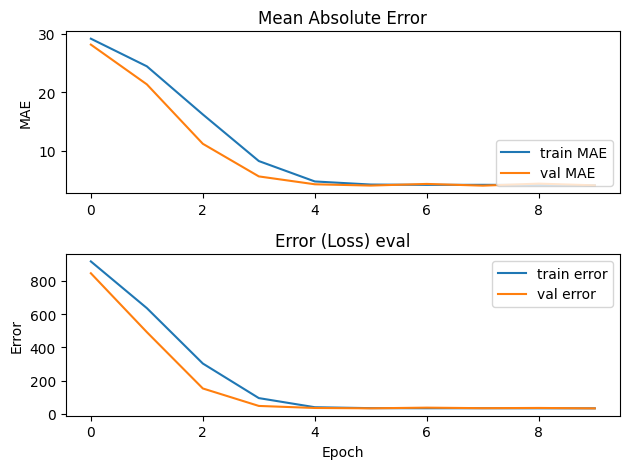

In [29]:
plot_history(history_train_cnn)

## 11 - Model Evaluation

### 11.1 - Spectrogram-Domain Evaluation
Compute MSE and MAE directly on mel spectrograms of the test set

In [30]:
# evaluate the CNN on the test set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)
print("test loss (MSE):", test_loss, "test MAE:", test_mae)

120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 33.6343 - mae: 4.0650
test loss (MSE): 33.5599250793457 test MAE: 4.061441421508789


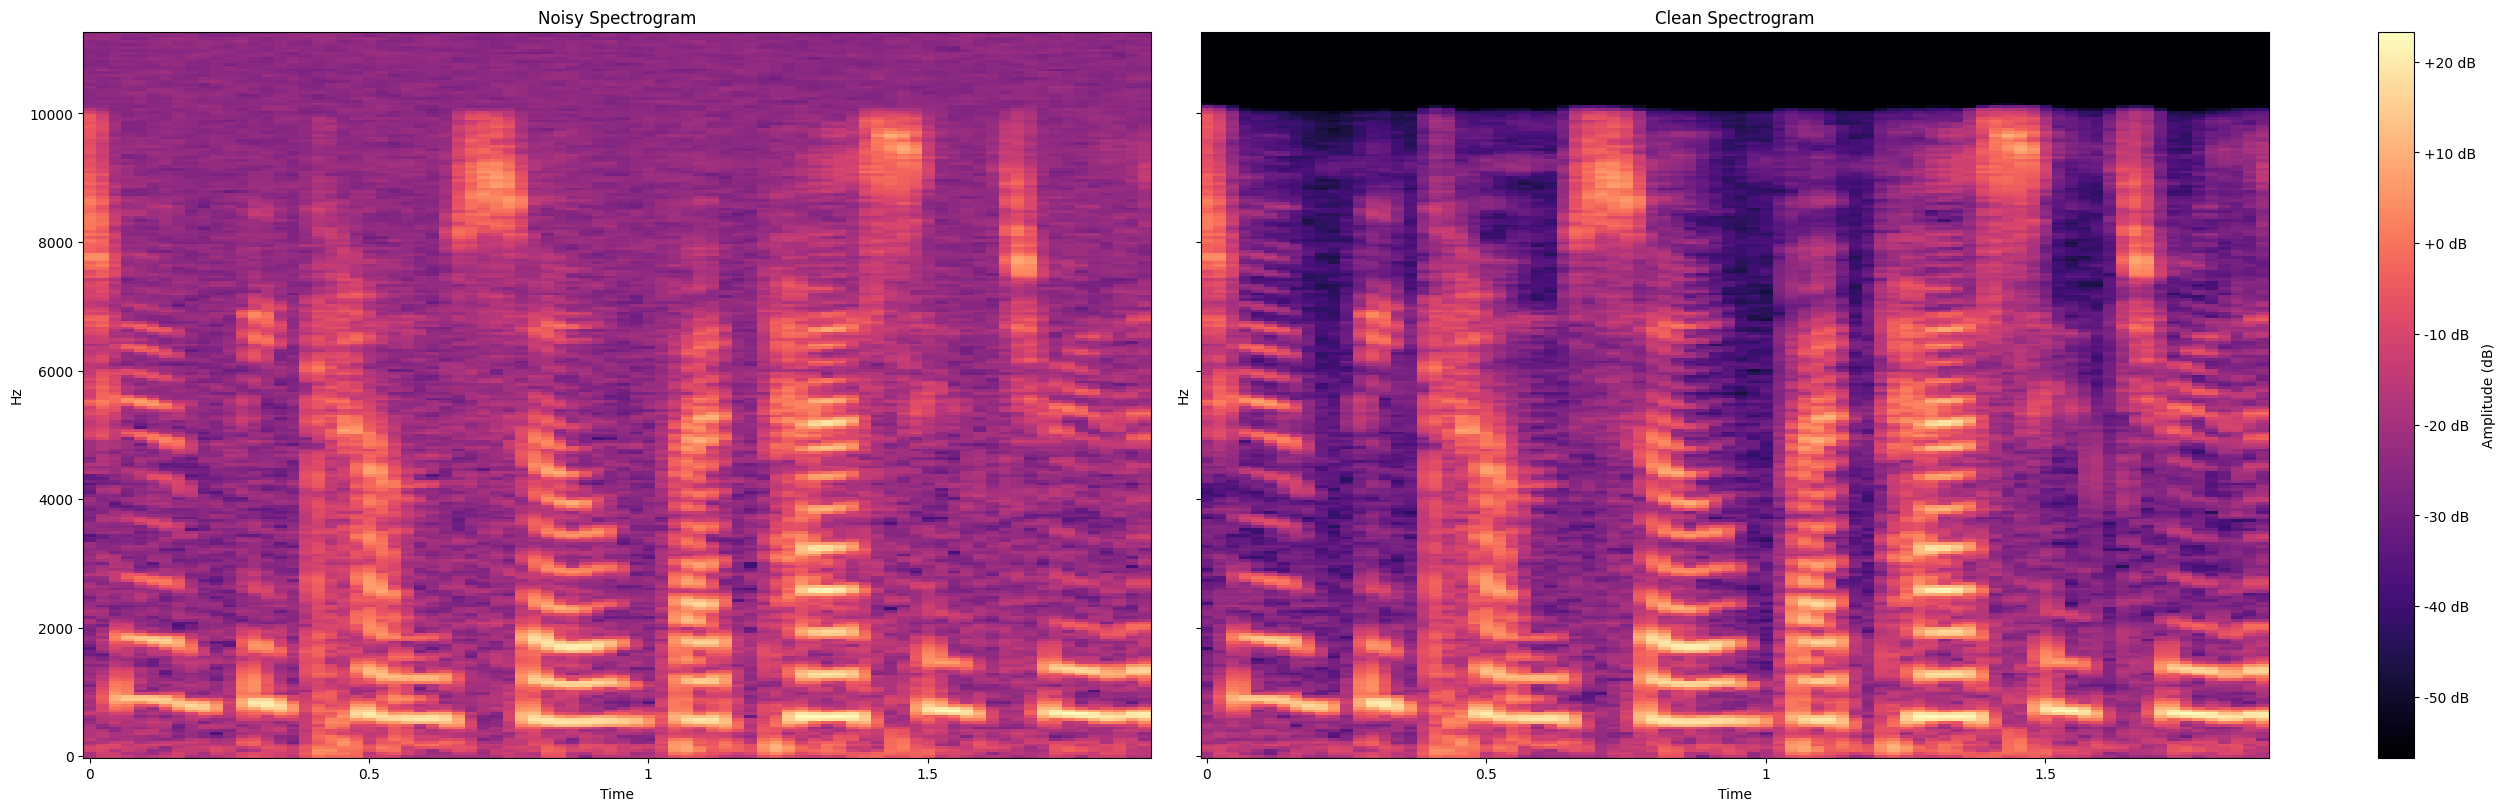

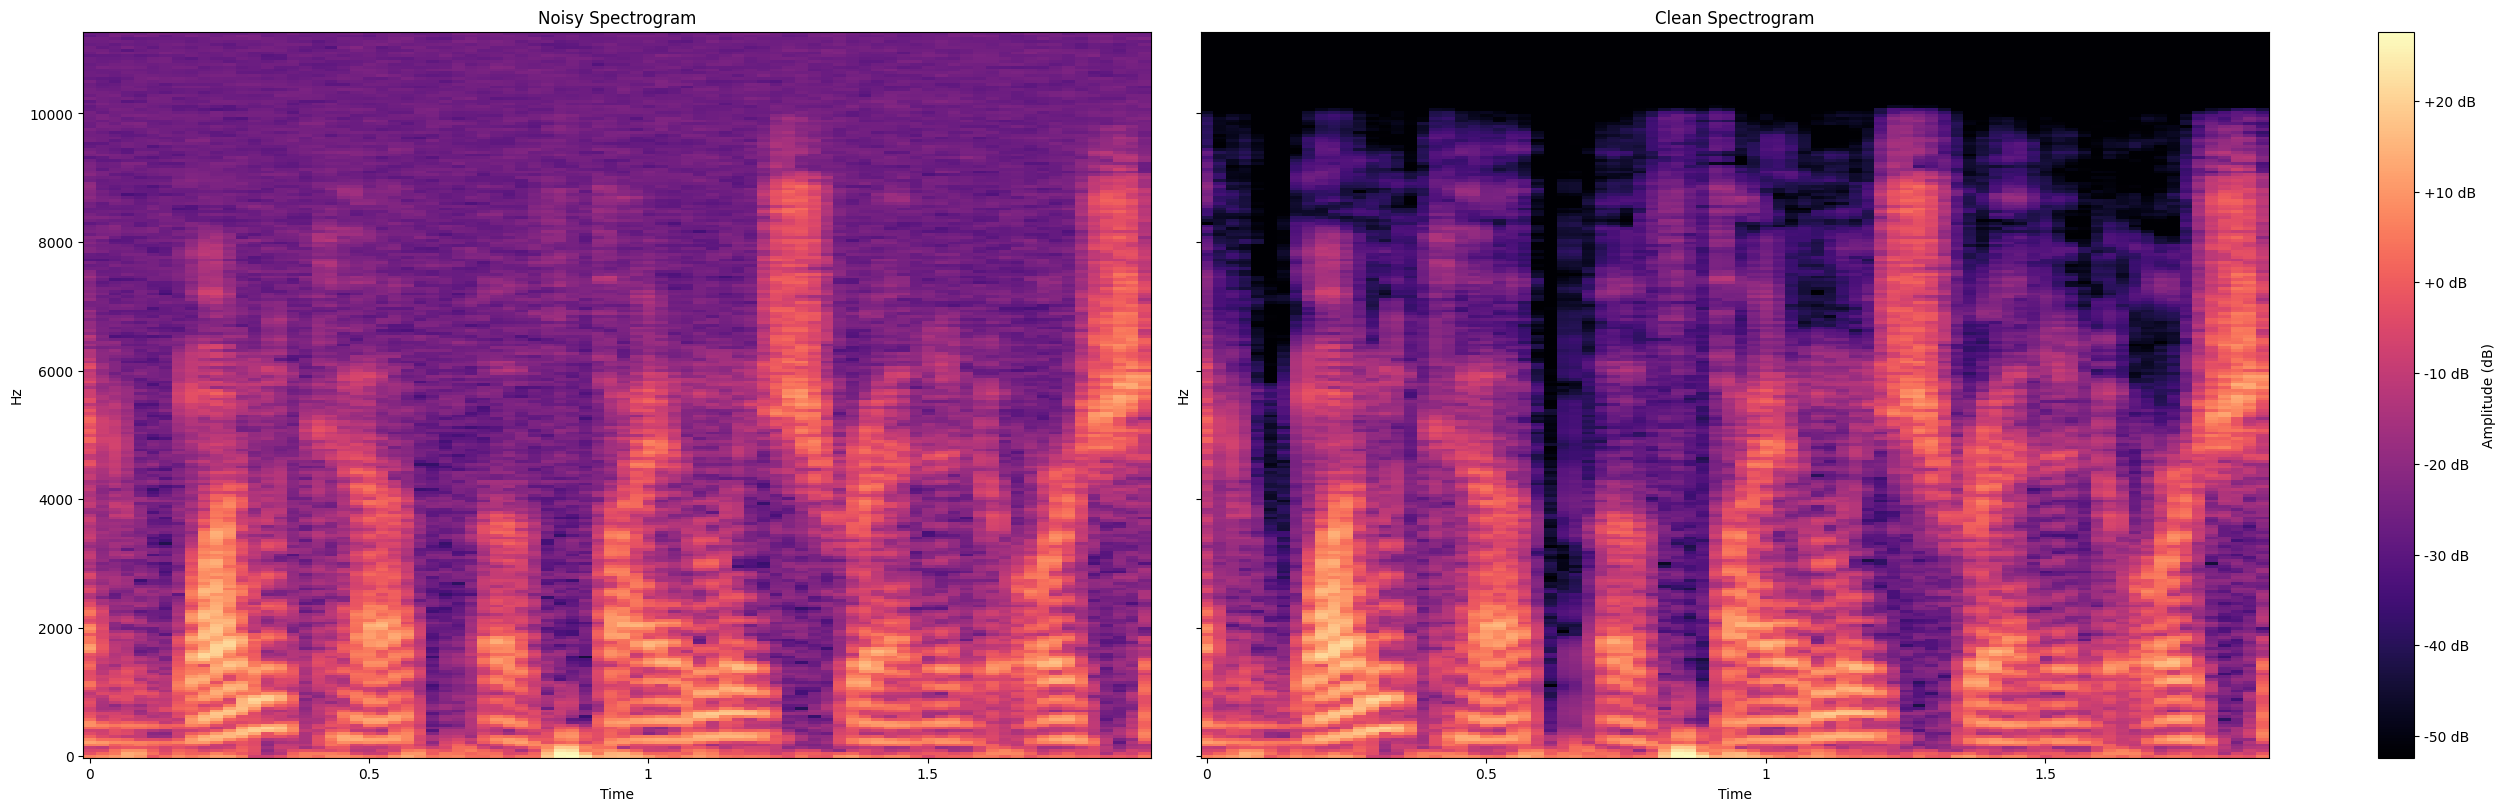

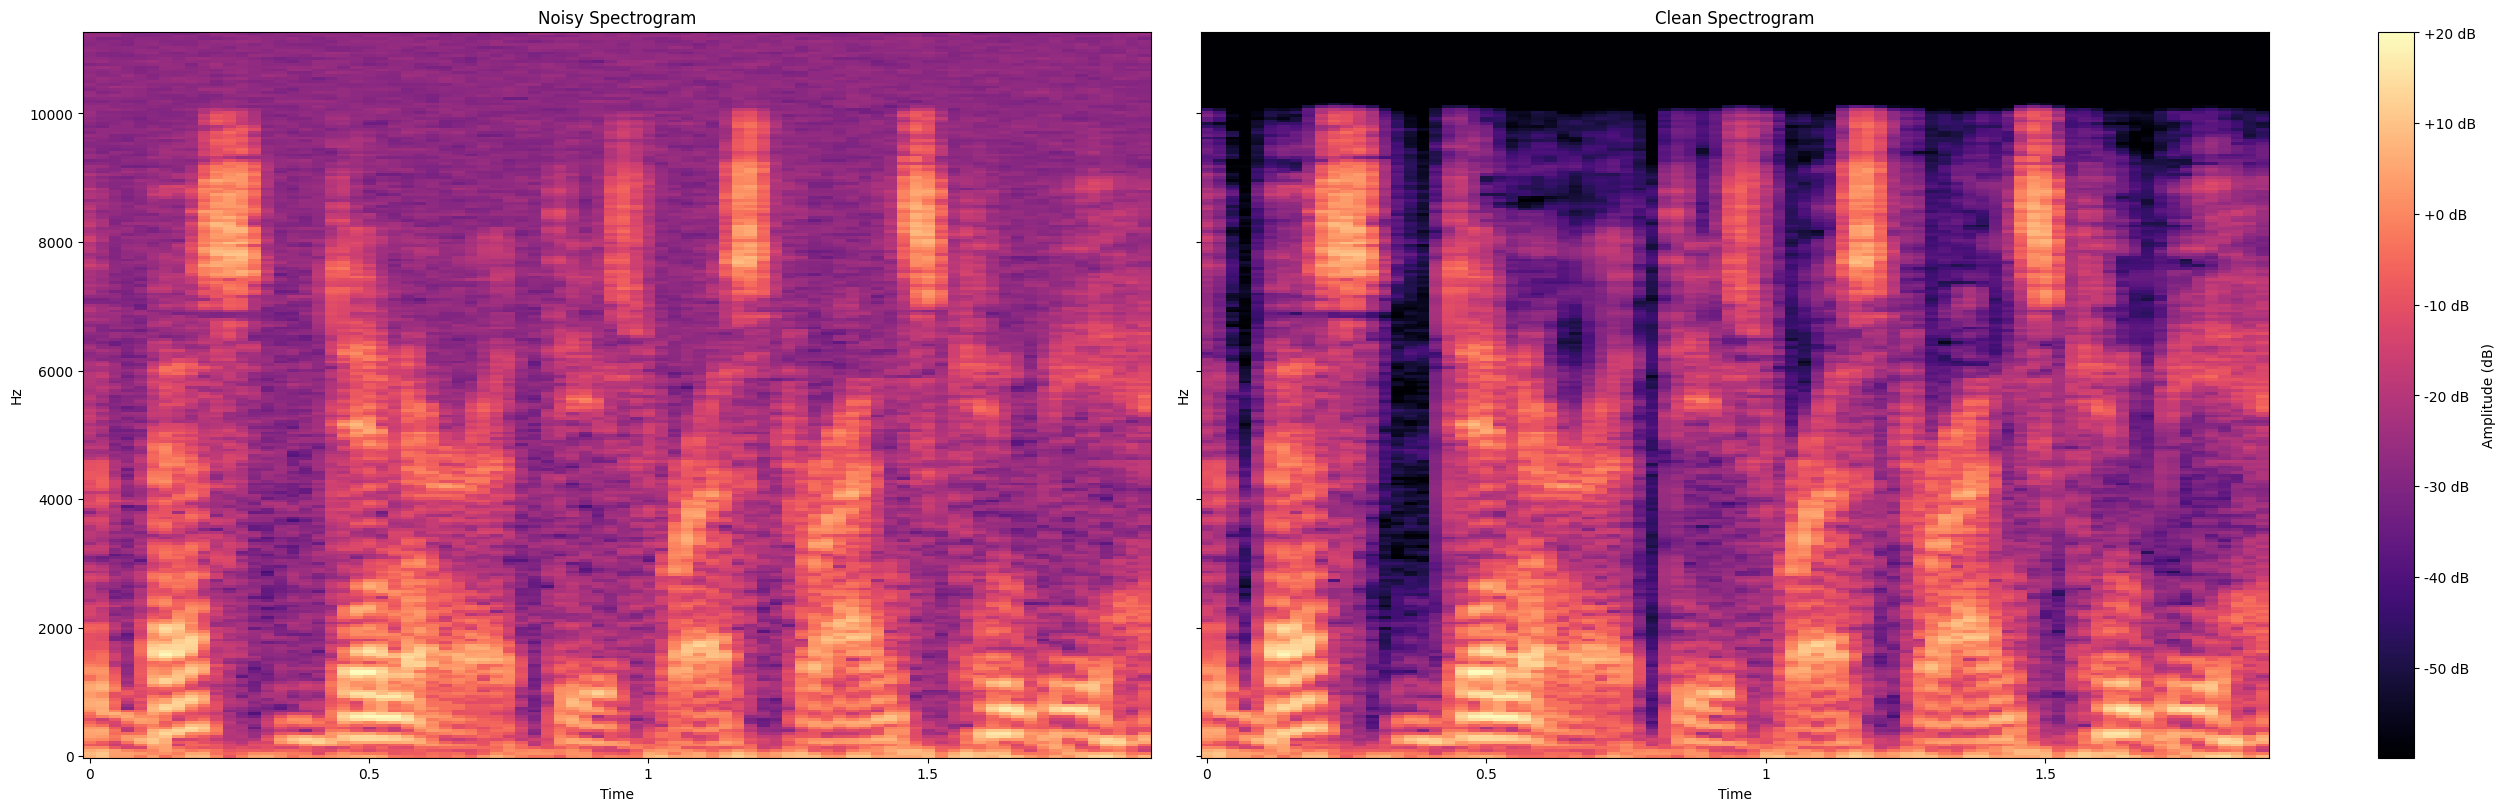

In [31]:
for (spec_noisy, spec_clean) in zip(X_test[:3], y_test[:3]):
  plot_spectrograms(np.squeeze(spec_noisy), spec_clean)

### 11.2 - Audio-Domain Evaluation

To evaluate perceptual quality, we must convert spectrograms back to audio. For this, we use the Griffin-Lim algorithm.

In [32]:
def mel_db_to_audio(
    S_mel_db,
    sr,
    n_fft,
    hop_length,
    n_mels,
    power=2.0,
    center=False,
    n_iter=64,
):
    """
    Invert a mel power-in-dB spectrogram back to audio using Griffin-Lim.

    S_mel_db : np.ndarray, shape (n_mels, T)
        Mel spectrogram in dB (like your compute_mel_scaled_spectrogram output)
    """
    # dB -> power (invert power_to_db(..., ref=1.0))
    S_mel = librosa.db_to_power(S_mel_db, ref=1.0)

    # mel -> waveform (this does mel_to_stft + griffinlim under the hood)
    y = librosa.feature.inverse.mel_to_audio(
        S_mel,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        power=power,
        center=center,
        n_iter=n_iter,
    )

    return y

Test on a specific example and listen.

In [52]:


# X_test_noisy: noisy mel-dB inputs, shape (N, n_mels, T, 1)
# y_test_clean: clean mel-dB targets, same shape

idx = 30  # pick which example to listen to

# 1) get model prediction in mel-dB space
pred = model.predict(X_test[idx:idx+1])     # shape (1, n_mels, T, 1)
print(f"pred.shape: {pred.shape}")
pred_mel_db = pred[0, :, :, 0]              # shape (n_mels, T)
print(f"pred_mel_db.shape: {pred_mel_db.shape}")

# 2) invert predicted mel-dB to audio
y_denoised = mel_db_to_audio(
    pred_mel_db,
    sr=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
    center=True,
)
print(f"y_denoised.shape: {y_denoised.shape}")


# 3) (optional) also invert clean target for comparison
print(f"y_test.shape: {y_test.shape}")
clean_mel_db = y_test[idx, :, :]
print(f"clean_mel_db.shape: {clean_mel_db.shape}")

y_clean = mel_db_to_audio(
    clean_mel_db,
    sr=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
    center=True,
)
print(f"y_clean.shape: {y_clean.shape}")

# 4) also invert noisy input for comparison
noisy_mel_db = X_test[idx, :, :, 0]  # shape (n_mels, T)
print(f"noisy_mel_db.shape: {noisy_mel_db.shape}")

y_noisy = mel_db_to_audio(
    noisy_mel_db,
    sr=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
    center=True,
)
print(f"y_noisy.shape: {y_noisy.shape}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
pred.shape: (1, 256, 84, 1)
pred_mel_db.shape: (256, 84)
y_denoised.shape: (42496,)
y_test.shape: (3831, 256, 84)
clean_mel_db.shape: (256, 84)
y_clean.shape: (42496,)
noisy_mel_db.shape: (256, 84)
y_noisy.shape: (42496,)


In [54]:
Audio(data=y_noisy, rate=SAMPLE_RATE)     # Noisy input

In [55]:
Audio(data=y_denoised, rate=SAMPLE_RATE)

In [56]:
Audio(data=y_clean, rate=SAMPLE_RATE)